<a href="https://colab.research.google.com/github/baanujan-18/Statistical-Learning-e20030/blob/main/Assignment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kalman Filter Assignment

This notebook contains:

1. Analytical derivation of the linear Kalman filter  
2. A one-dimensional scalar example  
3. A two-dimensional constant-velocity GPS position estimator  
4. Simulation, visualization, and an optional real-data workflow  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

np.set_printoptions(precision=4, suppress=True)

# 1. Analytical Derivation

Consider the linear-Gaussian state-space model

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1},
$$

$$
y_k^- = H_kx_k^- + z_k,
$$

where

$$
x_{k-1}^+ \sim \mathcal{N}(m_{k-1},P_{k-1}),
$$

$$
w_{k-1} \sim \mathcal{N}(0,\Sigma_p),
\qquad
z_k \sim \mathcal{N}(0,\Sigma_m).
$$

The state, process noise, and measurement noise are assumed to be mutually independent.

## 1.1 Predicted State Distribution

The predicted state is

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}.
$$

Because the previous state and the process noise are Gaussian, the predicted state is also Gaussian:

$$
x_k^- \sim \mathcal{N}(m_k^-,P_k^-).
$$

The predicted mean is

$$
m_k^- = \mathbb{E}[x_k^-].
$$

Substituting the state equation,

$$
m_k^- =
\mathbb{E}
\left[
A_{k-1}x_{k-1}^+
+
G_{k-1}w_{k-1}
\right].
$$

Using the linearity of expectation,

$$
m_k^- =
A_{k-1}\mathbb{E}[x_{k-1}^+]
+
G_{k-1}\mathbb{E}[w_{k-1}].
$$

Since

$$
\mathbb{E}[x_{k-1}^+] = m_{k-1}
$$

and

$$
\mathbb{E}[w_{k-1}] = 0,
$$

we obtain

$$
\boxed{
m_k^- = A_{k-1}m_{k-1}
}.
$$

The predicted covariance is

$$
P_k^- = \operatorname{Var}(x_k^-).
$$

Therefore,

$$
P_k^- =
\operatorname{Var}
\left(
A_{k-1}x_{k-1}^+
+
G_{k-1}w_{k-1}
\right).
$$

Because the previous state and the process noise are independent,

$$
P_k^- =
A_{k-1}P_{k-1}A_{k-1}^{T}
+
G_{k-1}\Sigma_pG_{k-1}^{T}.
$$

Thus,

$$
\boxed{
x_k^- \sim
\mathcal{N}
\left(
A_{k-1}m_{k-1},
A_{k-1}P_{k-1}A_{k-1}^{T}
+
G_{k-1}\Sigma_pG_{k-1}^{T}
\right)
}.
$$

## 1.2 Predicted Measurement Distribution

The predicted measurement is

$$
y_k^- = H_kx_k^- + z_k.
$$

Since the predicted state is Gaussian,

$$
x_k^- \sim \mathcal{N}(m_k^-,P_k^-),
$$

and the measurement noise is Gaussian,

$$
z_k \sim \mathcal{N}(0,\Sigma_m),
$$

the predicted measurement is also Gaussian.

The predicted measurement mean is

$$
\mathbb{E}[y_k^-]
=
\mathbb{E}[H_kx_k^- + z_k].
$$

Using the linearity of expectation,

$$
\mathbb{E}[y_k^-]
=
H_k\mathbb{E}[x_k^-]
+
\mathbb{E}[z_k].
$$

Since

$$
\mathbb{E}[x_k^-]=m_k^-
$$

and

$$
\mathbb{E}[z_k]=0,
$$

we obtain

$$
\boxed{
\mathbb{E}[y_k^-]=H_km_k^-
}.
$$

The predicted measurement covariance is

$$
\operatorname{Var}(y_k^-)
=
\operatorname{Var}(H_kx_k^-+z_k).
$$

Because the predicted state and the measurement noise are independent,

$$
\operatorname{Var}(y_k^-)
=
H_kP_k^-H_k^T+\Sigma_m.
$$

Therefore,

$$
\boxed{
y_k^- \sim
\mathcal{N}
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right)
}.
$$

## 1.3 Joint State–Measurement Distribution

We now find the joint distribution of the predicted state and the predicted measurement.

The predicted state is

$$
x_k^- \sim \mathcal{N}(m_k^-,P_k^-),
$$

and the predicted measurement is

$$
y_k^- = H_kx_k^- + z_k.
$$

The mean of the joint random vector is

$$
\mathbb{E}
\left[
\begin{bmatrix}
x_k^- \\
y_k^-
\end{bmatrix}
\right]
=
\begin{bmatrix}
\mathbb{E}[x_k^-] \\
\mathbb{E}[y_k^-]
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
\mathbb{E}
\left[
\begin{bmatrix}
x_k^- \\
y_k^-
\end{bmatrix}
\right]
=
\begin{bmatrix}
m_k^- \\
H_km_k^-
\end{bmatrix}
}.
$$

The cross-covariance between the predicted state and the predicted measurement is

$$
\operatorname{Cov}(x_k^-,y_k^-)
=
\operatorname{Cov}
\left(
x_k^-,
H_kx_k^-+z_k
\right).
$$

Since the predicted state and the measurement noise are independent,

$$
\operatorname{Cov}(x_k^-,z_k)=0.
$$

Thus,

$$
\operatorname{Cov}(x_k^-,y_k^-)
=
\operatorname{Cov}(x_k^-,H_kx_k^-).
$$

Therefore,

$$
\boxed{
\operatorname{Cov}(x_k^-,y_k^-)
=
P_k^-H_k^T
}.
$$

Similarly,

$$
\boxed{
\operatorname{Cov}(y_k^-,x_k^-)
=
H_kP_k^-
}.
$$

The covariance of the predicted measurement is

$$
\boxed{
\operatorname{Var}(y_k^-)
=
H_kP_k^-H_k^T+\Sigma_m
}.
$$

Therefore, the joint distribution is

$$
\boxed{
\begin{bmatrix}
x_k^- \\
y_k^-
\end{bmatrix}
\sim
\mathcal{N}
\left(
\begin{bmatrix}
m_k^- \\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- & P_k^-H_k^T \\
H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right)
}.
$$

## 1.4 Measurement Update and Conditional Distribution

At time step \(k\), the measurement random variable \(y_k^-\) takes the observed numerical value

$$
y_k^- = y_k^{\mathrm{obs}}.
$$

The posterior state is defined as the conditional random variable

$$
x_k^+
=
\left(
x_k^- \mid y_k^- = y_k^{\mathrm{obs}}
\right).
$$

Since the joint distribution of \(x_k^-\) and \(y_k^-\) is Gaussian, the conditional distribution is also Gaussian:

$$
\boxed{
x_k^+ \sim \mathcal{N}(m_k,P_k)
}.
$$

Define the innovation covariance as

$$
S_k
=
H_kP_k^-H_k^T+\Sigma_m.
$$

The Kalman gain is

$$
\boxed{
K_k
=
P_k^-H_k^TS_k^{-1}
}.
$$

Equivalently,

$$
\boxed{
K_k
=
P_k^-H_k^T
\left(
H_kP_k^-H_k^T+\Sigma_m
\right)^{-1}
}.
$$

The innovation, or measurement residual, is

$$
\boxed{
v_k
=
y_k^{\mathrm{obs}}-H_km_k^-
}.
$$

The updated mean is

$$
m_k
=
m_k^-
+
P_k^-H_k^TS_k^{-1}
\left(
y_k^{\mathrm{obs}}-H_km_k^-
\right).
$$

Using the Kalman gain, this becomes

$$
\boxed{
m_k
=
m_k^-+K_k
\left(
y_k^{\mathrm{obs}}-H_km_k^-
\right)
}.
$$

The updated covariance is

$$
P_k
=
P_k^-
-
P_k^-H_k^TS_k^{-1}H_kP_k^-.
$$

Using the Kalman gain,

$$
\boxed{
P_k
=
\left(
I-K_kH_k
\right)P_k^-
}.
$$

Therefore, the posterior distribution is

$$
\boxed{
x_k^+
\sim
\mathcal{N}
\left(
m_k^-+K_k
\left(
y_k^{\mathrm{obs}}-H_km_k^-
\right),
\left(
I-K_kH_k
\right)P_k^-
\right)
}.
$$

## 1.5 Conditional Expectation and Conditional Variance

From the conditional Gaussian distribution,

$$
x_k^+
=
\left(
x_k^- \mid y_k^- = y_k^{\mathrm{obs}}
\right)
\sim
\mathcal{N}(m_k,P_k).
$$

Therefore, the conditional expectation is

$$
\boxed{
\mathbb{E}
\left[
x_k^-
\mid
y_k^- = y_k^{\mathrm{obs}}
\right]
=
m_k
}.
$$

Using the Kalman filter update equation,

$$
\boxed{
\mathbb{E}
\left[
x_k^-
\mid
y_k^- = y_k^{\mathrm{obs}}
\right]
=
m_k^-
+
P_k^-H_k^T
\left(
H_kP_k^-H_k^T+\Sigma_m
\right)^{-1}
\left(
y_k^{\mathrm{obs}}-H_km_k^-
\right)
}.
$$

The conditional variance is

$$
\boxed{
\operatorname{Var}
\left(
x_k^-
\mid
y_k^- = y_k^{\mathrm{obs}}
\right)
=
P_k
}.
$$

Using the covariance update formula,

$$
\boxed{
\operatorname{Var}
\left(
x_k^-
\mid
y_k^- = y_k^{\mathrm{obs}}
\right)
=
P_k^-
-
P_k^-H_k^T
\left(
H_kP_k^-H_k^T+\Sigma_m
\right)^{-1}
H_kP_k^-
}.
$$

Equivalently,

$$
\boxed{
\operatorname{Var}
\left(
x_k^-
\mid
y_k^- = y_k^{\mathrm{obs}}
\right)
=
\left(
I-K_kH_k
\right)P_k^-
}.
$$

# 2. One-Dimensional Example

Consider the scalar linear-Gaussian model

$$
x_k^- = a x_{k-1}^+ + w_{k-1},
$$

where

$$
w_{k-1} \sim \mathcal{N}(0,q),
$$

and

$$
y_k^- = h x_k^- + z_k,
$$

where

$$
z_k \sim \mathcal{N}(0,r).
$$

The initial state is

$$
x_0 \sim \mathcal{N}(m_0,P_0).
$$

Let

$$
Y_k =
\left\{
y_1^{\mathrm{obs}},
\ldots,
y_k^{\mathrm{obs}}
\right\}.
$$

## 2.1 Prediction Step

The predicted mean is

$$
m_k^- = \mathbb{E}[x_k^-].
$$

Substituting the scalar state equation,

$$
m_k^- =
\mathbb{E}
\left[
a x_{k-1}^+ + w_{k-1}
\right].
$$

Using the linearity of expectation,

$$
m_k^- =
a\mathbb{E}[x_{k-1}^+]
+
\mathbb{E}[w_{k-1}].
$$

Since

$$
\mathbb{E}[x_{k-1}^+] = m_{k-1}
$$

and

$$
\mathbb{E}[w_{k-1}] = 0,
$$

we obtain

$$
\boxed{
m_k^- = a m_{k-1}
}.
$$

The predicted variance is

$$
P_k^- =
\operatorname{Var}(x_k^-).
$$

Therefore,

$$
P_k^- =
\operatorname{Var}
\left(
a x_{k-1}^+ + w_{k-1}
\right).
$$

Because the state and process noise are independent,

$$
P_k^- =
a^2\operatorname{Var}(x_{k-1}^+)
+
\operatorname{Var}(w_{k-1}).
$$

Thus,

$$
\boxed{
P_k^- = a^2P_{k-1}+q
}.
$$

Therefore, the predicted state distribution is

$$
\boxed{
x_k^- \mid Y_{k-1}
\sim
\mathcal{N}
\left(
a m_{k-1},
a^2P_{k-1}+q
\right)
}.
$$

## 2.2 Measurement Update

The predicted measurement is

$$
y_k^- = h x_k^- + z_k.
$$

The innovation, or measurement residual, is

$$
v_k
=
y_k^{\mathrm{obs}} - h m_k^-.
$$

The innovation variance is

$$
S_k
=
\operatorname{Var}(y_k^-).
$$

Since

$$
y_k^- = h x_k^- + z_k,
$$

we have

$$
S_k
=
h^2P_k^- + r.
$$

Therefore,

$$
\boxed{
S_k = h^2P_k^- + r
}.
$$

The scalar Kalman gain is

$$
K_k
=
\frac{P_k^-h}{S_k}.
$$

Substituting the expression for \(S_k\),

$$
\boxed{
K_k
=
\frac{P_k^-h}
{h^2P_k^-+r}
}.
$$

The updated mean is

$$
m_k
=
m_k^- + K_kv_k.
$$

Substituting the innovation,

$$
m_k
=
m_k^- +
K_k
\left(
y_k^{\mathrm{obs}}-hm_k^-
\right).
$$

Therefore,

$$
\boxed{
m_k
=
m_k^- +
\frac{P_k^-h}
{h^2P_k^-+r}
\left(
y_k^{\mathrm{obs}}-hm_k^-
\right)
}.
$$

The updated variance is

$$
P_k
=
\left(
1-K_kh
\right)P_k^-.
$$

Substituting the Kalman gain,

$$
P_k
=
\left(
1-
\frac{P_k^-h^2}
{h^2P_k^-+r}
\right)P_k^-.
$$

Therefore,

$$
\boxed{
P_k
=
\frac{rP_k^-}
{h^2P_k^-+r}
}.
$$

Thus, the posterior state distribution is

$$
\boxed{
x_k^+ \mid Y_k
\sim
\mathcal{N}(m_k,P_k)
}.
$$

## 2.3 Predictive Measurement Distribution

Before observing the measurement \(y_k\), the predicted state distribution is

$$
x_k^- \mid Y_{k-1}
\sim
\mathcal{N}(m_k^-,P_k^-).
$$

The measurement equation is

$$
y_k = h x_k^- + z_k,
$$

where

$$
z_k \sim \mathcal{N}(0,r).
$$

The conditional mean of the predicted measurement is

$$
\mathbb{E}
\left[
y_k \mid Y_{k-1}
\right]
=
\mathbb{E}
\left[
h x_k^- + z_k
\mid
Y_{k-1}
\right].
$$

Using the linearity of expectation,

$$
\mathbb{E}
\left[
y_k \mid Y_{k-1}
\right]
=
h\mathbb{E}
\left[
x_k^- \mid Y_{k-1}
\right]
+
\mathbb{E}[z_k].
$$

Since

$$
\mathbb{E}
\left[
x_k^- \mid Y_{k-1}
\right]
=
m_k^-
$$

and

$$
\mathbb{E}[z_k]=0,
$$

we obtain

$$
\boxed{
\mathbb{E}
\left[
y_k \mid Y_{k-1}
\right]
=
h m_k^-
}.
$$

The conditional variance is

$$
\operatorname{Var}
\left(
y_k \mid Y_{k-1}
\right)
=
\operatorname{Var}
\left(
h x_k^- + z_k
\mid Y_{k-1}
\right).
$$

Because the predicted state and measurement noise are independent,

$$
\operatorname{Var}
\left(
y_k \mid Y_{k-1}
\right)
=
h^2P_k^- + r.
$$

Therefore, the predictive measurement distribution is

$$
\boxed{
p
\left(
y_k \mid Y_{k-1}
\right)
=
\mathcal{N}
\left(
h m_k^-,
h^2P_k^- + r
\right)
}.
$$

## 2.4 Posterior-Predictive Measurement Distribution

After observing the measurement \(y_k^{\mathrm{obs}}\), the posterior state distribution is

$$
x_k^+ \mid Y_k
\sim
\mathcal{N}(m_k,P_k).
$$

A new measurement generated from the posterior state satisfies

$$
y_k^{\mathrm{new}}
=
h x_k^+ + z_k,
$$

where

$$
z_k \sim \mathcal{N}(0,r).
$$

The posterior-predictive mean is

$$
\mathbb{E}
\left[
y_k^{\mathrm{new}} \mid Y_k
\right]
=
\mathbb{E}
\left[
h x_k^+ + z_k
\mid
Y_k
\right].
$$

Using the linearity of expectation,

$$
\mathbb{E}
\left[
y_k^{\mathrm{new}} \mid Y_k
\right]
=
h\mathbb{E}
\left[
x_k^+ \mid Y_k
\right]
+
\mathbb{E}[z_k].
$$

Since

$$
\mathbb{E}
\left[
x_k^+ \mid Y_k
\right]
=
m_k
$$

and

$$
\mathbb{E}[z_k]=0,
$$

we obtain

$$
\boxed{
\mathbb{E}
\left[
y_k^{\mathrm{new}} \mid Y_k
\right]
=
h m_k
}.
$$

The posterior-predictive variance is

$$
\operatorname{Var}
\left(
y_k^{\mathrm{new}} \mid Y_k
\right)
=
\operatorname{Var}
\left(
h x_k^+ + z_k
\mid Y_k
\right).
$$

Because the posterior state and measurement noise are independent,

$$
\operatorname{Var}
\left(
y_k^{\mathrm{new}} \mid Y_k
\right)
=
h^2P_k+r.
$$

Therefore, the posterior-predictive measurement distribution is

$$
\boxed{
p
\left(
y_k^{\mathrm{new}} \mid Y_k
\right)
=
\mathcal{N}
\left(
h m_k,
h^2P_k+r
\right)
}.
$$

This distribution is narrower than the predictive distribution when the posterior variance \(P_k\) is smaller than the prior variance \(P_k^-\).

#2.5 Animation of the Prior and Posterior Distributions.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# Numerical values
a = 1.0
h = 1.0
q = 0.05
r = 1.0

m0 = 0.0
P0 = 10.0

true_x0 = 0.0
number_of_steps = 40
random_seed = 7


# Random-number generator
rng = np.random.default_rng(random_seed)


# Initial values
true_x = true_x0
m = m0
P = P0


# Storage
true_states = []
measurements = []

prior_means = []
prior_variances = []

posterior_means = []
posterior_variances = []

kalman_gains = []


# Kalman-filter loop
for k in range(number_of_steps):

    # Simulate the true state
    process_noise = rng.normal(
        loc=0.0,
        scale=np.sqrt(q)
    )

    true_x = a * true_x + process_noise


    # Simulate the noisy measurement
    measurement_noise = rng.normal(
        loc=0.0,
        scale=np.sqrt(r)
    )

    y_observed = h * true_x + measurement_noise


    # Prediction step
    m_minus = a * m

    P_minus = a**2 * P + q


    # Innovation
    innovation = y_observed - h * m_minus

    S = h**2 * P_minus + r


    # Kalman gain
    K = P_minus * h / S


    # Correction step
    m = m_minus + K * innovation

    P = (1.0 - K * h) * P_minus


    # Save results
    true_states.append(true_x)
    measurements.append(y_observed)

    prior_means.append(m_minus)
    prior_variances.append(P_minus)

    posterior_means.append(m)
    posterior_variances.append(P)

    kalman_gains.append(K)


# Convert lists to arrays
true_states = np.asarray(true_states)
measurements = np.asarray(measurements)

prior_means = np.asarray(prior_means)
prior_variances = np.asarray(prior_variances)

posterior_means = np.asarray(posterior_means)
posterior_variances = np.asarray(posterior_variances)

kalman_gains = np.asarray(kalman_gains)


# Create the animation
fig, ax = plt.subplots(figsize=(9, 5))


def update(frame):

    ax.clear()

    true_state = true_states[frame]
    measurement = measurements[frame]

    prior_mean = prior_means[frame]
    prior_variance = prior_variances[frame]

    posterior_mean = posterior_means[frame]
    posterior_variance = posterior_variances[frame]


    prior_std = np.sqrt(prior_variance)
    posterior_std = np.sqrt(posterior_variance)


    maximum_std = max(
        prior_std,
        posterior_std
    )


    x_min = min(
        prior_mean,
        posterior_mean,
        true_state
    ) - 4.5 * maximum_std


    x_max = max(
        prior_mean,
        posterior_mean,
        true_state
    ) + 4.5 * maximum_std


    x_values = np.linspace(
        x_min,
        x_max,
        500
    )


    prior_pdf = norm.pdf(
        x_values,
        loc=prior_mean,
        scale=prior_std
    )


    posterior_pdf = norm.pdf(
        x_values,
        loc=posterior_mean,
        scale=posterior_std
    )


    ax.plot(
        x_values,
        prior_pdf,
        linewidth=2,
        label="Prior distribution"
    )


    ax.plot(
        x_values,
        posterior_pdf,
        linewidth=2,
        label="Posterior distribution"
    )


    ax.axvline(
        true_state,
        linestyle="--",
        linewidth=2,
        label="True state"
    )


    ax.axvline(
        measurement / h,
        linestyle=":",
        linewidth=2,
        label="Observed measurement"
    )


    ax.set_title(
        f"Scalar Kalman Filter: Step {frame + 1}"
    )

    ax.set_xlabel("State value")

    ax.set_ylabel("Probability density")

    ax.grid(True)

    ax.legend(loc="upper right")


animation = FuncAnimation(
    fig,
    update,
    frames=number_of_steps,
    interval=300,
    repeat=False
)


plt.close(fig)


HTML(animation.to_jshtml())

# 3. Two-Dimensional Position Estimation

Consider a two-dimensional constant-velocity dynamical system.

The hidden state at time step \(k\) is

$$
x_k
=
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix},
$$

where

- \(p_x(k)\) is the position in the \(x\)-direction,
- \(p_y(k)\) is the position in the \(y\)-direction,
- \(v_x(k)\) is the velocity in the \(x\)-direction,
- \(v_y(k)\) is the velocity in the \(y\)-direction.

## 3.1 Constant-Velocity State Model

Assume that the sampling interval is \(\Delta t\).

Under the constant-velocity assumption,

$$
p_x(k)
=
p_x(k-1)
+
\Delta t\,v_x(k-1),
$$

$$
p_y(k)
=
p_y(k-1)
+
\Delta t\,v_y(k-1),
$$

$$
v_x(k)
=
v_x(k-1),
$$

and

$$
v_y(k)
=
v_y(k-1).
$$

These equations can be written in matrix form as

$$
x_k
=
A x_{k-1},
$$

where

$$
\boxed{
A
=
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
}.
$$

Therefore,

$$
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1) \\
p_y(k-1) \\
v_x(k-1) \\
v_y(k-1)
\end{bmatrix}.
$$

## 3.2 Measurement Model

The measurement contains only the two position components.

Therefore,

$$
y_k
=
\begin{bmatrix}
p_x^{\mathrm{meas}}(k) \\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The measurement equation is

$$
y_k
=
H x_k + z_k,
$$

where \(z_k\) is the measurement noise.

The state is

$$
x_k
=
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}.
$$

Since only position is measured, the measurement matrix must select the first two components of the state.

Thus,

$$
\boxed{
H
=
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
}.
$$

Therefore,

$$
y_k
=
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
+
z_k.
$$

Hence,

$$
y_k
=
\begin{bmatrix}
p_x(k) \\
p_y(k)
\end{bmatrix}
+
z_k.
$$

The measurement noise is modeled as

$$
z_k
\sim
\mathcal{N}(0,\Sigma_m).
$$

If the GPS noise has the same variance in both directions, then

$$
\Sigma_m
=
\sigma_{\mathrm{GPS}}^2 I_2.
$$

## 3.3 Process Noise Model

The constant-velocity model does not include acceleration directly. Therefore, random acceleration is used to represent process uncertainty.

Let the process-noise vector be

$$
w_{k-1}
=
\begin{bmatrix}
a_x(k-1) \\
a_y(k-1)
\end{bmatrix},
$$

where

- \(a_x(k-1)\) is the random acceleration in the \(x\)-direction,
- \(a_y(k-1)\) is the random acceleration in the \(y\)-direction.

The process noise is assumed to be Gaussian:

$$
w_{k-1}
\sim
\mathcal{N}(0,\Sigma_p).
$$

Over one sampling interval \(\Delta t\), acceleration affects both position and velocity.

For the \(x\)-direction,

$$
p_x(k)
=
p_x(k-1)
+
\Delta t\,v_x(k-1)
+
\frac{1}{2}\Delta t^2 a_x(k-1),
$$

$$
v_x(k)
=
v_x(k-1)
+
\Delta t\,a_x(k-1).
$$

For the \(y\)-direction,

$$
p_y(k)
=
p_y(k-1)
+
\Delta t\,v_y(k-1)
+
\frac{1}{2}\Delta t^2 a_y(k-1),
$$

$$
v_y(k)
=
v_y(k-1)
+
\Delta t\,a_y(k-1).
$$

The complete state equation is

$$
x_k
=
A x_{k-1}
+
G w_{k-1}.
$$

The process-noise input matrix is

$$
\boxed{
G
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0 \\
0 & \frac{1}{2}\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}
}.
$$

Therefore,

$$
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
=
A
\begin{bmatrix}
p_x(k-1) \\
p_y(k-1) \\
v_x(k-1) \\
v_y(k-1)
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0 \\
0 & \frac{1}{2}\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x(k-1) \\
a_y(k-1)
\end{bmatrix}.
$$

If the acceleration noise is independent in both directions with variance \(\sigma_a^2\), then

$$
\Sigma_p
=
\sigma_a^2 I_2.
$$

The state-space process covariance is

$$
\boxed{
Q
=
G\Sigma_pG^T
}.
$$

## 3.4 Complete Two-Dimensional Kalman Filter Model

The complete state-space model is

$$
x_k^-
=
A x_{k-1}^+
+
G w_{k-1},
$$

and

$$
y_k
=
H x_k^-
+
z_k.
$$

The process noise and measurement noise are

$$
w_{k-1}
\sim
\mathcal{N}(0,\Sigma_p),
$$

and

$$
z_k
\sim
\mathcal{N}(0,\Sigma_m).
$$

The state-transition matrix is

$$
A
=
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

The measurement matrix is

$$
H
=
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}.
$$

The process-noise input matrix is

$$
G
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0 \\
0 & \frac{1}{2}\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}.
$$

If

$$
\Sigma_p
=
\sigma_a^2 I_2,
$$

then the state-space process covariance is

$$
Q
=
G\Sigma_pG^T.
$$

Therefore,

$$
Q
=
\sigma_a^2
\begin{bmatrix}
\frac{1}{4}\Delta t^4
&
0
&
\frac{1}{2}\Delta t^3
&
0
\\
0
&
\frac{1}{4}\Delta t^4
&
0
&
\frac{1}{2}\Delta t^3
\\
\frac{1}{2}\Delta t^3
&
0
&
\Delta t^2
&
0
\\
0
&
\frac{1}{2}\Delta t^3
&
0
&
\Delta t^2
\end{bmatrix}.
$$

If the GPS measurement noise has standard deviation
\(\sigma_{\mathrm{GPS}}\) in both directions, then

$$
\Sigma_m
=
R
=
\sigma_{\mathrm{GPS}}^2 I_2.
$$

Thus,

$$
R
=
\begin{bmatrix}
\sigma_{\mathrm{GPS}}^2 & 0 \\
0 & \sigma_{\mathrm{GPS}}^2
\end{bmatrix}.
$$

The Kalman filter prediction equations are

$$
m_k^-
=
A m_{k-1},
$$

and

$$
P_k^-
=
A P_{k-1}A^T
+
Q.
$$

The innovation is

$$
v_k
=
y_k
-
H m_k^-.
$$

The innovation covariance is

$$
S_k
=
H P_k^-H^T
+
R.
$$

The Kalman gain is

$$
K_k
=
P_k^-H^T S_k^{-1}.
$$

The updated state estimate is

$$
m_k
=
m_k^-
+
K_kv_k.
$$

The updated covariance is

$$
P_k
=
\left(
I-K_kH
\right)P_k^-.
$$

#3.5 Python Method for Filtering Noisy GPS Measurements.

In [3]:
import numpy as np


def kalman_filter_gps(
    gps_measurements,
    dt=1.0,
    acceleration_std=0.5,
    gps_std=3.0,
    initial_velocity=(0.0, 0.0)
):
    """
    Filter a sequence of noisy 2D GPS position measurements.

    Parameters
    ----------
    gps_measurements : array-like, shape (N, 2)
        Each row contains [x_position, y_position].

    dt : float
        Sampling interval.

    acceleration_std : float
        Standard deviation of the process acceleration noise.

    gps_std : float
        Standard deviation of the GPS measurement noise.

    initial_velocity : tuple
        Initial velocity estimate (vx, vy).

    Returns
    -------
    estimates : ndarray, shape (N, 4)
        Filtered state estimates:
        [x_position, y_position, x_velocity, y_velocity].

    covariances : ndarray, shape (N, 4, 4)
        Posterior covariance matrices.
    """

    gps_measurements = np.asarray(
        gps_measurements,
        dtype=float
    )


    # Check the measurement shape
    if gps_measurements.ndim != 2:
        raise ValueError(
            "gps_measurements must be a two-dimensional array."
        )


    if gps_measurements.shape[1] != 2:
        raise ValueError(
            "Each GPS measurement must contain x and y positions."
        )


    if len(gps_measurements) == 0:
        raise ValueError(
            "gps_measurements cannot be empty."
        )


    if dt <= 0:
        raise ValueError(
            "dt must be greater than zero."
        )


    # State-transition matrix
    A = np.array([
        [1.0, 0.0, dt, 0.0],
        [0.0, 1.0, 0.0, dt],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])


    # Measurement matrix
    H = np.array([
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0]
    ])


    # Process-noise input matrix
    G = np.array([
        [0.5 * dt**2, 0.0],
        [0.0, 0.5 * dt**2],
        [dt, 0.0],
        [0.0, dt]
    ])


    # Process-noise covariance
    Sigma_p = acceleration_std**2 * np.eye(2)


    # State-space process covariance
    Q = G @ Sigma_p @ G.T


    # GPS measurement covariance
    R = gps_std**2 * np.eye(2)


    # Initial state estimate
    m = np.array([
        gps_measurements[0, 0],
        gps_measurements[0, 1],
        initial_velocity[0],
        initial_velocity[1]
    ])


    # Initial covariance
    P = np.diag([
        gps_std**2,
        gps_std**2,
        100.0,
        100.0
    ])


    # Identity matrix
    I = np.eye(4)


    # Storage
    estimates = []
    covariances = []


    # Kalman-filter loop
    for y_k in gps_measurements:

        # -------------------------
        # Prediction step
        # -------------------------

        m_minus = A @ m

        P_minus = A @ P @ A.T + Q


        # -------------------------
        # Innovation
        # -------------------------

        innovation = y_k - H @ m_minus

        S = H @ P_minus @ H.T + R


        # -------------------------
        # Kalman gain
        # -------------------------

        K = np.linalg.solve(
            S.T,
            (P_minus @ H.T).T
        ).T


        # -------------------------
        # Correction step
        # -------------------------

        m = m_minus + K @ innovation


        # Joseph covariance update
        I_minus_KH = I - K @ H

        P = (
            I_minus_KH
            @ P_minus
            @ I_minus_KH.T
            +
            K @ R @ K.T
        )


        # Save the posterior estimate
        estimates.append(m.copy())

        covariances.append(P.copy())


    return (
        np.asarray(estimates),
        np.asarray(covariances)
    )

In [4]:
import numpy as np


def simulate_gps_data(
    number_of_steps=150,
    dt=1.0,
    initial_position=(0.0, 0.0),
    initial_velocity=(1.2, 0.6),
    acceleration_std=0.08,
    gps_std=3.0,
    random_seed=10
):
    """
    Generate a two-dimensional trajectory and noisy GPS measurements.

    Returns
    -------
    true_states : ndarray, shape (N, 4)
        True states:
        [x_position, y_position, x_velocity, y_velocity].

    gps_measurements : ndarray, shape (N, 2)
        Noisy GPS position measurements.
    """

    rng = np.random.default_rng(random_seed)


    # Initial state
    state = np.array([
        initial_position[0],
        initial_position[1],
        initial_velocity[0],
        initial_velocity[1]
    ], dtype=float)


    # Storage
    true_states = []
    gps_measurements = []


    for k in range(number_of_steps):

        # Random acceleration
        acceleration = rng.normal(
            loc=0.0,
            scale=acceleration_std,
            size=2
        )


        # Update true x-position
        state[0] = (
            state[0]
            +
            dt * state[2]
            +
            0.5 * dt**2 * acceleration[0]
        )


        # Update true y-position
        state[1] = (
            state[1]
            +
            dt * state[3]
            +
            0.5 * dt**2 * acceleration[1]
        )


        # Update true x-velocity
        state[2] = (
            state[2]
            +
            dt * acceleration[0]
        )


        # Update true y-velocity
        state[3] = (
            state[3]
            +
            dt * acceleration[1]
        )


        # GPS measurement noise
        measurement_noise = rng.normal(
            loc=0.0,
            scale=gps_std,
            size=2
        )


        # Noisy GPS measurement
        measurement = (
            state[0:2]
            +
            measurement_noise
        )


        # Save results
        true_states.append(state.copy())

        gps_measurements.append(measurement.copy())


    return (
        np.asarray(true_states),
        np.asarray(gps_measurements)
    )


# Numerical values
number_of_steps = 150
dt = 1.0
acceleration_std = 0.08
gps_std = 3.0


# Generate data
true_states, gps_measurements = simulate_gps_data(
    number_of_steps=number_of_steps,
    dt=dt,
    initial_position=(0.0, 0.0),
    initial_velocity=(1.2, 0.6),
    acceleration_std=acceleration_std,
    gps_std=gps_std,
    random_seed=10
)


print("True states shape:")
print(true_states.shape)

print()

print("GPS measurements shape:")
print(gps_measurements.shape)

print()

print("First five true states:")
print(true_states[:5])

print()

print("First five GPS measurements:")
print(gps_measurements[:5])

True states shape:
(150, 4)

GPS measurements shape:
(150, 2)

First five true states:
[[1.1559 0.571  1.1117 0.542 ]
 [2.2577 1.1181 1.0918 0.5521]
 [3.3685 1.6521 1.1299 0.5161]
 [4.4846 2.1661 1.1024 0.5119]
 [5.5992 2.604  1.1268 0.3638]]

First five GPS measurements:
[[-1.1895  1.3719]
 [ 4.7868  3.6919]
 [ 1.1037 -0.7923]
 [ 1.5678 -1.2373]
 [ 5.068   3.8815]]


#3.7 Apply the Kalman Filter to the Simulated GPS Data.

In [5]:
# Apply the Kalman filter to the simulated GPS measurements

estimated_states, estimated_covariances = kalman_filter_gps(
    gps_measurements=gps_measurements,
    dt=dt,
    acceleration_std=acceleration_std,
    gps_std=gps_std,
    initial_velocity=(0.0, 0.0)
)


print("Estimated states shape:")
print(estimated_states.shape)

print()

print("Estimated covariance shape:")
print(estimated_covariances.shape)

print()

print("First five estimated states:")
print(estimated_states[:5])

print()

print("Final estimated state:")
print(estimated_states[-1])

print()

print("Final true state:")
print(true_states[-1])

Estimated states shape:
(150, 4)

Estimated covariance shape:
(150, 4, 4)

First five estimated states:
[[-1.1895  1.3719  0.      0.    ]
 [ 3.6621  3.2553  2.8599  1.1102]
 [ 2.7719  0.7957  1.2621 -0.4108]
 [ 2.5625 -0.583   0.7722 -0.733 ]
 [ 4.2404  1.3996  1.0198  0.0092]]

Final estimated state:
[-14.5338 -42.9674  -1.0317  -0.2087]

Final true state:
[-15.591  -40.3594  -1.2341   0.0578]


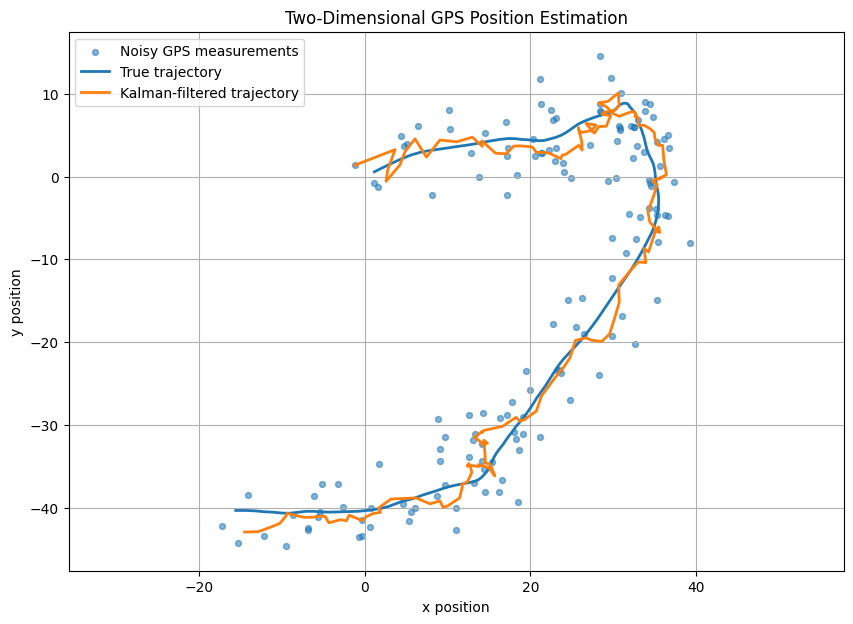

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 7))


# Plot noisy GPS measurements
plt.scatter(
    gps_measurements[:, 0],
    gps_measurements[:, 1],
    s=18,
    alpha=0.55,
    label="Noisy GPS measurements"
)


# Plot true trajectory
plt.plot(
    true_states[:, 0],
    true_states[:, 1],
    linewidth=2,
    label="True trajectory"
)


# Plot Kalman-filtered trajectory
plt.plot(
    estimated_states[:, 0],
    estimated_states[:, 1],
    linewidth=2,
    label="Kalman-filtered trajectory"
)


plt.xlabel("x position")

plt.ylabel("y position")

plt.title("Two-Dimensional GPS Position Estimation")

plt.grid(True)

plt.axis("equal")

plt.legend()

plt.show()

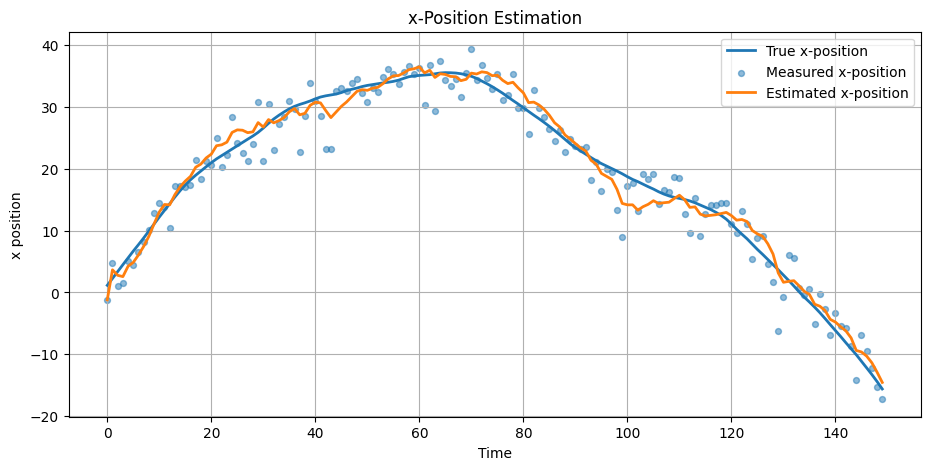

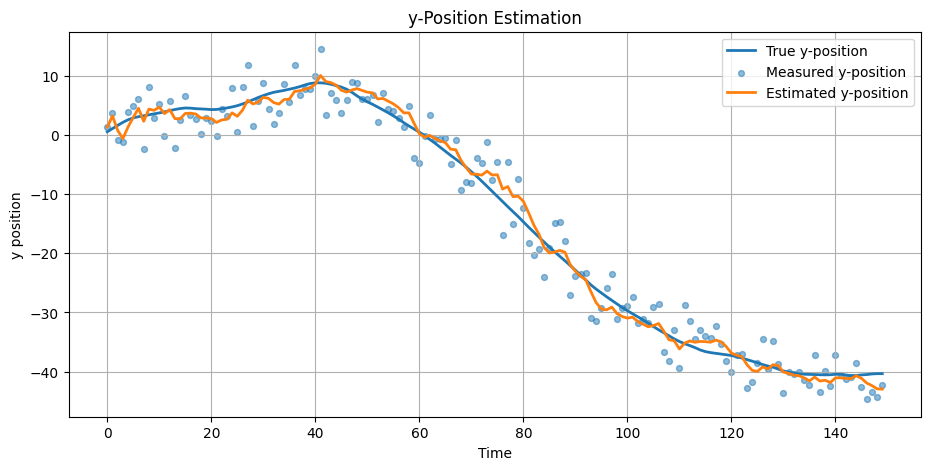

In [7]:
# Create the time axis
time = np.arange(number_of_steps) * dt


# Plot x-position
plt.figure(figsize=(11, 5))

plt.plot(
    time,
    true_states[:, 0],
    linewidth=2,
    label="True x-position"
)

plt.scatter(
    time,
    gps_measurements[:, 0],
    s=18,
    alpha=0.5,
    label="Measured x-position"
)

plt.plot(
    time,
    estimated_states[:, 0],
    linewidth=2,
    label="Estimated x-position"
)

plt.xlabel("Time")

plt.ylabel("x position")

plt.title("x-Position Estimation")

plt.grid(True)

plt.legend()

plt.show()


# Plot y-position
plt.figure(figsize=(11, 5))

plt.plot(
    time,
    true_states[:, 1],
    linewidth=2,
    label="True y-position"
)

plt.scatter(
    time,
    gps_measurements[:, 1],
    s=18,
    alpha=0.5,
    label="Measured y-position"
)

plt.plot(
    time,
    estimated_states[:, 1],
    linewidth=2,
    label="Estimated y-position"
)

plt.xlabel("Time")

plt.ylabel("y position")

plt.title("y-Position Estimation")

plt.grid(True)

plt.legend()

plt.show()

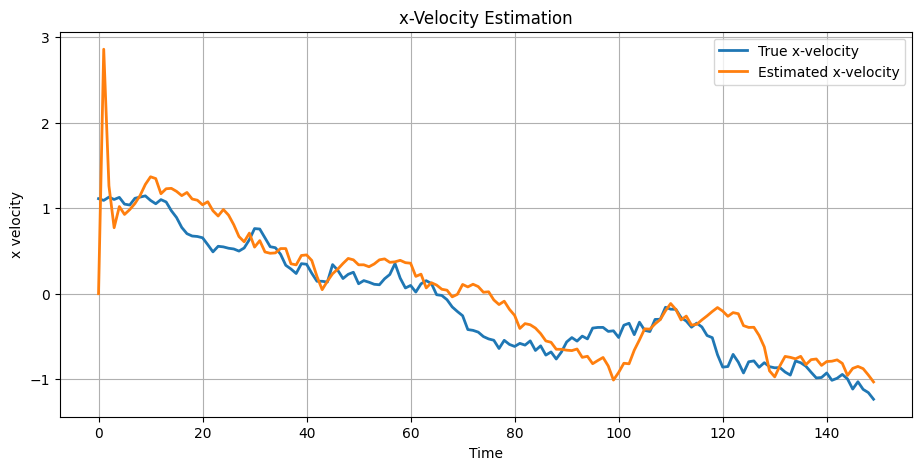

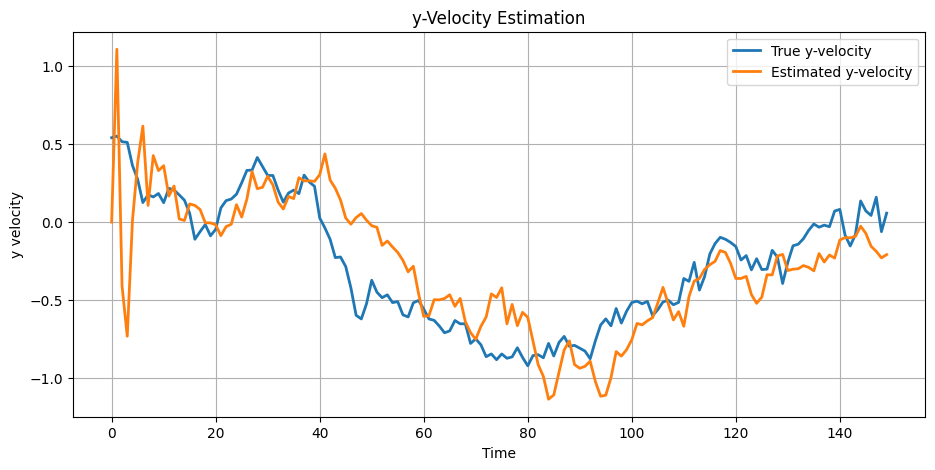

In [8]:
# Plot x-velocity
plt.figure(figsize=(11, 5))

plt.plot(
    time,
    true_states[:, 2],
    linewidth=2,
    label="True x-velocity"
)

plt.plot(
    time,
    estimated_states[:, 2],
    linewidth=2,
    label="Estimated x-velocity"
)

plt.xlabel("Time")

plt.ylabel("x velocity")

plt.title("x-Velocity Estimation")

plt.grid(True)

plt.legend()

plt.show()


# Plot y-velocity
plt.figure(figsize=(11, 5))

plt.plot(
    time,
    true_states[:, 3],
    linewidth=2,
    label="True y-velocity"
)

plt.plot(
    time,
    estimated_states[:, 3],
    linewidth=2,
    label="Estimated y-velocity"
)

plt.xlabel("Time")

plt.ylabel("y velocity")

plt.title("y-Velocity Estimation")

plt.grid(True)

plt.legend()

plt.show()

#3.11 Calculate the Position Estimation Error.

In [9]:
# Calculate the raw GPS position error

gps_position_errors = (
    gps_measurements
    -
    true_states[:, 0:2]
)


# Calculate the filtered position error

filtered_position_errors = (
    estimated_states[:, 0:2]
    -
    true_states[:, 0:2]
)


# Root Mean Square Error for raw GPS measurements

gps_rmse = np.sqrt(
    np.mean(
        np.sum(
            gps_position_errors**2,
            axis=1
        )
    )
)


# Root Mean Square Error for Kalman-filtered positions

filtered_rmse = np.sqrt(
    np.mean(
        np.sum(
            filtered_position_errors**2,
            axis=1
        )
    )
)


print("Raw GPS position RMSE:")

print(gps_rmse)

print()


print("Kalman-filtered position RMSE:")

print(filtered_rmse)

print()


# Calculate the percentage improvement

percentage_improvement = (
    (gps_rmse - filtered_rmse)
    /
    gps_rmse
) * 100.0


print("Percentage improvement:")

print(percentage_improvement, "%")

Raw GPS position RMSE:
4.317520383012846

Kalman-filtered position RMSE:
2.1633032322735364

Percentage improvement:
49.89477662259598 %


## 3.12 Discussion and Conclusion

The two-dimensional Kalman filter combines a constant-velocity motion model with noisy GPS position measurements.

The state vector is

$$
x_k
=
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}.
$$

Although the GPS sensor measures only position, the Kalman filter also estimates velocity because the state-transition model connects position and velocity.

The prediction step uses

$$
m_k^-
=
A m_{k-1},
$$

and

$$
P_k^-
=
A P_{k-1}A^T+Q.
$$

The correction step uses the GPS measurement to calculate the innovation

$$
v_k
=
y_k-Hm_k^-.
$$

The Kalman gain is

$$
K_k
=
P_k^-H^T
\left(
HP_k^-H^T+R
\right)^{-1}.
$$

The corrected state estimate is

$$
m_k
=
m_k^-+K_kv_k.
$$

The corrected covariance is

$$
P_k
=
\left(
I-K_kH
\right)P_k^-.
$$

The simulation results show that the Kalman-filtered trajectory is smoother than the raw GPS measurements and remains closer to the true trajectory.

The RMSE comparison also shows whether the Kalman filter improves position estimation. A smaller filtered RMSE indicates that the filter reduces measurement noise successfully.

The process-noise covariance \(Q\) determines how much uncertainty is assigned to the motion model. A larger value of \(Q\) makes the filter respond more quickly to changes in motion.

The measurement-noise covariance \(R\) determines how much confidence is placed in the GPS measurements. A larger value of \(R\) makes the filter rely more strongly on the predicted motion model.

Therefore, the Kalman filter provides an effective method for estimating two-dimensional position and velocity from noisy GPS measurements.

# 4. Final Summary

For the general linear Kalman filter, the prediction equations are

$$
\boxed{
m_k^- = A_{k-1}m_{k-1}
}
$$

and

$$
\boxed{
P_k^- =
A_{k-1}P_{k-1}A_{k-1}^T
+
G_{k-1}\Sigma_pG_{k-1}^T
}.
$$

The predicted measurement distribution is

$$
\boxed{
y_k^-
\sim
\mathcal{N}
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right)
}.
$$

The Kalman gain is

$$
\boxed{
K_k
=
P_k^-H_k^T
\left(
H_kP_k^-H_k^T+\Sigma_m
\right)^{-1}
}.
$$

The posterior mean is

$$
\boxed{
m_k
=
m_k^-+
K_k
\left(
y_k^{\mathrm{obs}}-H_km_k^-
\right)
}.
$$

The posterior covariance is

$$
\boxed{
P_k
=
\left(
I-K_kH_k
\right)P_k^-.
}
$$

For the scalar model,

$$
\boxed{
m_k^- = am_{k-1}
}
$$

and

$$
\boxed{
P_k^- = a^2P_{k-1}+q.
}
$$

The scalar Kalman gain is

$$
\boxed{
K_k
=
\frac{P_k^-h}
{h^2P_k^-+r}.
}
$$

For the two-dimensional constant-velocity model, the state-transition matrix is

$$
\boxed{
A
=
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}.
}
$$

The measurement matrix is

$$
\boxed{
H
=
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}.
}
$$

The process-noise input matrix is

$$
\boxed{
G
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0 \\
0 & \frac{1}{2}\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}.
}
$$

The Python implementation demonstrates that the Kalman filter can reduce noisy GPS measurement error while also estimating velocity from position measurements.

# 5. Completion Statement

This notebook presents the analytical derivation and numerical implementation of the Kalman filter.

The work includes:

1. Derivation of the predicted state mean and covariance.
2. Derivation of the predicted measurement distribution.
3. Derivation of the joint state-measurement distribution.
4. Derivation of the posterior mean and covariance.
5. A scalar linear-Gaussian Kalman filter example.
6. An animation comparing prior and posterior distributions.
7. A two-dimensional constant-velocity GPS model.
8. Python implementation of the two-dimensional Kalman filter.
9. Position, velocity, trajectory, and RMSE analysis.

The numerical results demonstrate that the Kalman filter reduces measurement noise and estimates unmeasured velocity using the dynamical model.